In [3]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
import pickle

import pandas as pd
import time
import os
import sys
import zarr
import napari 
import dask.array as da 

import h5py
import hdf5storage


from skimage import exposure
import matplotlib.pyplot as plt
#from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree

pythonPackagePath = os.path.abspath('/Users/valerie/LLSM-CME-ANALYSIS/Final/src')
sys.path.append(pythonPackagePath)
# from parallel import Detector
from gaussian_visualization import visualize_3D_gaussians

In [8]:
### LIGHT SHEET CORRECTION ANALYSIS ###

# # Import two pkl files and compare their detection counts
# df_MA2 = pd.read_pickle('/Volumes/ActiveNAS/Valerie/TransferFolder/20260130_ArpC3Comparison/20240603_MA2_Plate1-03-LatticeLightsheet-03_analysis/ch2/detection/channel_1_detections.pkl').reset_index()
# df_MA3 = pd.read_pickle('/Volumes/ActiveNAS/Valerie/TransferFolder/20260130_ArpC3Comparison/20240726_MA3_Abhi410_615_510_151515_15um-02_processed_analysis/ch1/detection/channel_1_detections.pkl').reset_index()
# #import the corresponing zarr files
# zarr_MA2 = zarr.open('/Volumes/ActiveNAS/Valerie/TransferFolder/20260130_ArpC3Comparison/20240603_MA2_Plate1-03-LatticeLightsheet-03_analysis/zarr_file/all_channels_data', mode='r')
# zarr_MA3 = zarr.open('/Volumes/ActiveNAS/Valerie/TransferFolder/20260130_ArpC3Comparison/20240726_MA3_Abhi410_615_510_151515_15um-02_processed_analysis/zarr_file/all_channels_data', mode='r')

# Load MA2 and MA3 datasets for comparison
base_dir_MA = r'/Volumes/ActiveNAS/Valerie/TransferFolder/'

# MA2 dataset
input_file_directory_MA2 = '20260130_ArpC3Comparison/20240603_MA2_Plate1-03-LatticeLightsheet-03_analysis/ch2/'
zarr_file_directory_MA2 =  '20260130_ArpC3Comparison/20240603_MA2_Plate1-03-LatticeLightsheet-03_analysis/zarr_file/all_channels_data'
zarr_full_path_MA2 = os.path.join(base_dir_MA, zarr_file_directory_MA2)
print(f"MA2 zarr path: {zarr_full_path_MA2}")
zarr_MA2 = zarr.open(zarr_full_path_MA2, mode='r')

path_to_detections_MA2 = os.path.join(base_dir_MA, input_file_directory_MA2) + 'detection/channel_1_detections.pkl'
df_MA2 = pd.read_pickle(path_to_detections_MA2).reset_index()

# MA3 dataset
input_file_directory_MA3 = '20260130_ArpC3Comparison/20240726_MA3_Abhi410_615_510_151515_15um-02_processed_analysis/ch1/'
zarr_file_directory_MA3 =  '20260130_ArpC3Comparison/20240726_MA3_Abhi410_615_510_151515_15um-02_processed_analysis/zarr_file/all_channels_data'
zarr_full_path_MA3 = os.path.join(base_dir_MA, zarr_file_directory_MA3)
zarr_MA3 = zarr.open(zarr_full_path_MA3, mode='r')

path_to_detections_MA3 = os.path.join(base_dir_MA, input_file_directory_MA3) + 'detection/channel_1_detections.pkl'
df_MA3 = pd.read_pickle(path_to_detections_MA3).reset_index()

print(f"MA2 zarr shape: {zarr_MA2.shape}")
print(f"MA3 zarr shape: {zarr_MA3.shape}")
print(f"MA2 detections: {len(df_MA2)}")
print(f"MA3 detections: {len(df_MA3)}")
print(f"MA2 detections in frame 0: {len(df_MA2[df_MA2['frame'] == 0])}")
print(f"MA3 detections in frame 0: {len(df_MA3[df_MA3['frame'] == 0])}")

MA2 zarr path: /Volumes/ActiveNAS/Valerie/TransferFolder/20260130_ArpC3Comparison/20240603_MA2_Plate1-03-LatticeLightsheet-03_analysis/zarr_file/all_channels_data
MA2 zarr shape: (128, 2, 114, 2048, 406)
MA3 zarr shape: (150, 3, 114, 2048, 303)
MA2 detections: 338409
MA3 detections: 244060
MA2 detections in frame 0: 2907
MA3 detections in frame 0: 1872


In [10]:
def calculate_lightsheet_mask(zarr_array, frame_idx=0, channel_idx=0, percentile_threshold=5):
    """
    Calculate a 3D binary mask of the light sheet illuminated region.
    
    Parameters:
    - zarr_array: Zarr array with shape [T, C, Z, Y, X]
    - frame_idx: Frame index to analyze (default 0)
    - channel_idx: Channel index to use for mask calculation (default 0)
    - percentile_threshold: Percentile threshold for identifying illuminated regions (default 5)
    
    Returns:
    - mask: 3D boolean array where True indicates illuminated regions
    - illuminated_fraction: Fraction of voxels that are illuminated
    """
    # Extract the 3D volume for the specified frame and channel
    volume = zarr_array[frame_idx, channel_idx, :, :, :]
    
    # Calculate intensity threshold (5th percentile to exclude background)
    threshold = np.percentile(volume, percentile_threshold)
    
    # Create binary mask where intensity is above threshold
    mask = volume > threshold
    
    # Calculate fraction of illuminated voxels
    illuminated_fraction = np.sum(mask) / mask.size
    
    print(f"Intensity threshold (5th percentile): {threshold:.2f}")
    print(f"Illuminated fraction: {illuminated_fraction:.4f}")
    
    return mask, illuminated_fraction

# Calculate light sheet mask for MA2 dataset
mask_MA2, illum_frac_MA2 = calculate_lightsheet_mask(zarr_MA2, frame_idx=0, channel_idx=0)
# Calculate light sheet mask for MA3 dataset
mask_MA3, illum_frac_MA3 = calculate_lightsheet_mask(zarr_MA3, frame_idx=0, channel_idx=0)

Intensity threshold (5th percentile): 0.00
Illuminated fraction: 0.5102
Intensity threshold (5th percentile): 0.00
Illuminated fraction: 0.3451


In [11]:
# Create napari visualization to validate the light sheet mask
# This shows frame 0 with the light sheet mask overlay

# Get frame 0 data
frame_idx = 0
channel_idx = 0
image_data = zarr_MA2[frame_idx, channel_idx, :, :, :]

# Create napari viewer
viewer_lightsheet = napari.Viewer()

# Add the raw image data
viewer_lightsheet.add_image(image_data, name='MA2 Frame 0', colormap='gray', blending='translucent')

# Add the light sheet mask as a labels layer with transparency
viewer_lightsheet.add_labels(mask_MA2.astype(int), name='Light Sheet Mask', opacity=0.3)

print("Napari viewer created with light sheet mask overlay")
print("The mask (shown in color) indicates the illuminated light sheet region")
print("Empty/dark regions are excluded from the mask")

Napari viewer created with light sheet mask overlay
The mask (shown in color) indicates the illuminated light sheet region
Empty/dark regions are excluded from the mask


In [12]:
# Create napari visualization to validate the light sheet mask
# This shows frame 0 with the light sheet mask overlay

# Get frame 0 data
frame_idx = 0
channel_idx = 0
image_data = zarr_MA3[frame_idx, channel_idx, :, :, :]

# Create napari viewer
viewer_lightsheet = napari.Viewer()

# Add the raw image data
viewer_lightsheet.add_image(image_data, name='MA3 Frame 0', colormap='gray', blending='translucent')

# Add the light sheet mask as a labels layer with transparency
viewer_lightsheet.add_labels(mask_MA3.astype(int), name='Light Sheet Mask', opacity=0.3)

print("Napari viewer created with light sheet mask overlay")
print("The mask (shown in color) indicates the illuminated light sheet region")
print("Empty/dark regions are excluded from the mask")

Napari viewer created with light sheet mask overlay
The mask (shown in color) indicates the illuminated light sheet region
Empty/dark regions are excluded from the mask


In [13]:
# ==============================================================================
# FUNCTION TO ANALYZE A SINGLE DATASET WITH LIGHTSHEET CORRECTION
# ==============================================================================

def analyze_dataset_with_corrections(df, zarr_array, dataset_name, voxel_x, voxel_y, voxel_z,
                                     y_frac=1.0, z_range=None, amp_threshold=0,
                                     use_lightsheet_mask=True, frame_idx=0, channel_idx=0):
    """
    Analyze a single dataset with flexible corrections for volume and light sheet

    Parameters:
    - df: DataFrame with detections (must have 'frame' column and mu_x, mu_y, mu_z coordinates)
    - zarr_array: Zarr array with shape [T, C, Z, Y, X]
    - dataset_name: Name for reporting
    - voxel_x, voxel_y, voxel_z: Voxel sizes in microns
    - y_frac: Fraction of Y dimension to use (centered), default 1.0 (full range)
    - z_range: Tuple (z_min_pixel, z_max_pixel) to define Z range, or None for full range
    - amp_threshold: Amplitude threshold for filtering detections
    - use_lightsheet_mask: If True, only count detections within light sheet mask
    - frame_idx: Frame index to analyze (default 0)
    - channel_idx: Channel index for background calculation (default 0)

    Returns: dict with all metrics
    """
    print(f"\n{'='*80}")
    print(f"Analyzing {dataset_name}")
    print(f"{'='*80}")

    # Get dimensions
    print(f"\nZarr array shape: {zarr_array.shape}")
    print(f"Dimensions: T={zarr_array.shape[0]}, C={zarr_array.shape[1]}, Z={zarr_array.shape[2]}, Y={zarr_array.shape[3]}, X={zarr_array.shape[4]}")

    # Calculate X dimension
    full_x_um = zarr_array.shape[4] * voxel_x

    # Calculate CENTERED Y range
    y_pixels_total = zarr_array.shape[3]
    y_pixels_to_use = int(y_pixels_total * y_frac)
    y_min_pixel = int((y_pixels_total - y_pixels_to_use) / 2)
    y_max_pixel = y_min_pixel + y_pixels_to_use
    corrected_y_um = y_pixels_to_use * voxel_y

    # Calculate Z range
    if z_range is None:
        z_min_pixel = 0
        z_max_pixel = zarr_array.shape[2]
    else:
        z_min_pixel, z_max_pixel = z_range

    z_pixels_to_use = z_max_pixel - z_min_pixel
    corrected_z_um = z_pixels_to_use * voxel_z

    print(f"\nVolume dimensions:")
    print(f"  X: {full_x_um:.2f} µm ({zarr_array.shape[4]} pixels, full range)")
    print(f"  Y: {corrected_y_um:.2f} µm ({y_pixels_to_use} pixels, CENTERED from {y_min_pixel} to {y_max_pixel})")
    print(f"  Z: {corrected_z_um:.2f} µm ({z_pixels_to_use} pixels, from {z_min_pixel} to {z_max_pixel})")

    # Calculate light sheet mask if requested
    if use_lightsheet_mask:
        print(f"\nCalculating light sheet mask...")
        mask, illuminated_fraction = calculate_lightsheet_mask(zarr_array, frame_idx=frame_idx, channel_idx=channel_idx)

        # Crop mask to the Y and Z ranges
        mask_cropped = mask[z_min_pixel:z_max_pixel, y_min_pixel:y_max_pixel, :]

        # Calculate corrected volume based on illuminated voxels
        illuminated_voxels = np.sum(mask_cropped)
        corrected_volume_um3 = illuminated_voxels * voxel_x * voxel_y * voxel_z

        print(f"  Illuminated voxels in corrected region: {illuminated_voxels:,}")
        print(f"  Corrected volume (light sheet only): {corrected_volume_um3:.2f} µm³")
    else:
        # Use full rectangular volume
        corrected_volume_um3 = full_x_um * corrected_y_um * corrected_z_um
        mask_cropped = None
        print(f"  Corrected volume (rectangular): {corrected_volume_um3:.2f} µm³")

    # Get detections for specified frame
    df_frame = df[df['frame'] == frame_idx]

    print(f"\nFrame {frame_idx} total detections: {len(df_frame)}")
    if len(df_frame) > 0:
        print(f"Coordinate ranges in data:")
        print(f"  X: {df_frame['mu_x'].min():.1f} - {df_frame['mu_x'].max():.1f}")
        print(f"  Y: {df_frame['mu_y'].min():.1f} - {df_frame['mu_y'].max():.1f}")
        print(f"  Z: {df_frame['mu_z'].min():.1f} - {df_frame['mu_z'].max():.1f}")

    # Filter to corrected Y and Z ranges
    df_corrected = df_frame[
        (df_frame['mu_y'] >= y_min_pixel) & (df_frame['mu_y'] <= y_max_pixel) &
        (df_frame['mu_z'] >= z_min_pixel) & (df_frame['mu_z'] <= z_max_pixel)
    ]

    print(f"\nDetections in corrected Y+Z range: {len(df_corrected)}")
    if len(df_frame) > 0:
        print(f"  Percentage kept: {len(df_corrected)/len(df_frame)*100:.1f}%")

    # Apply light sheet mask filter if requested
    if use_lightsheet_mask and mask_cropped is not None:
        # Check each detection to see if it falls within the mask
        detections_in_mask = []
        for idx, row in df_corrected.iterrows():
            # Convert to integer pixel coordinates (relative to cropped region)
            z_idx = int(np.round(row['mu_z'])) - z_min_pixel
            y_idx = int(np.round(row['mu_y'])) - y_min_pixel
            x_idx = int(np.round(row['mu_x']))

            # Check bounds
            if (0 <= z_idx < mask_cropped.shape[0] and
                0 <= y_idx < mask_cropped.shape[1] and
                0 <= x_idx < mask_cropped.shape[2]):
                # Check if this voxel is illuminated
                if mask_cropped[z_idx, y_idx, x_idx]:
                    detections_in_mask.append(idx)

        df_corrected = df_corrected.loc[detections_in_mask]
        print(f"Detections within light sheet mask: {len(df_corrected)}")
        if len(df_corrected) > 0:
            print(f"  Percentage of Y+Z filtered detections in mask: {len(df_corrected)/len(df_frame)*100:.1f}%")

    # Calculate detection density
    num_detections = len(df_corrected)
    density = num_detections / corrected_volume_um3 if corrected_volume_um3 > 0 else 0

    print(f"\nDetection density:")
    print(f"  {density:.6f} detections/µm³")
    print(f"  {density*1000:.3f} detections/1000µm³")

    # Calculate background of the image
    image_region = zarr_array[frame_idx, channel_idx, z_min_pixel:z_max_pixel, y_min_pixel:y_max_pixel, :]

    background_10percentile = np.percentile(image_region, 10)
    background_mean = np.mean(image_region)
    background_median = np.median(image_region)

    print(f"\nImage background (frame {frame_idx}, channel {channel_idx}):")
    print(f"  10th percentile: {background_10percentile:.2f}")
    print(f"  Mean: {background_mean:.2f}")
    print(f"  Median: {background_median:.2f}")

    # Analyze detected spot amplitudes
    positive_spots = df_corrected[df_corrected['amplitude'] > amp_threshold]

    if len(positive_spots) > 0:
        avg_amplitude = positive_spots['amplitude'].mean()
        std_amplitude = positive_spots['amplitude'].std()
        median_amplitude = positive_spots['amplitude'].median()
        percentile_25 = positive_spots['amplitude'].quantile(0.25)
        percentile_75 = positive_spots['amplitude'].quantile(0.75)
        percentile_90 = positive_spots['amplitude'].quantile(0.90)

        print(f"\nDetected spot intensities (amplitude > {amp_threshold}):")
        print(f"  Count: {len(positive_spots)} ({len(positive_spots)/len(df_corrected)*100:.1f}%)")
        print(f"  Mean: {avg_amplitude:.2f} ± {std_amplitude:.2f}")
        print(f"  Median: {median_amplitude:.2f}")
        print(f"  25th-75th percentile: {percentile_25:.2f} - {percentile_75:.2f}")
        print(f"  90th percentile: {percentile_90:.2f}")
        print(f"  Range: {positive_spots['amplitude'].min():.2f} - {positive_spots['amplitude'].max():.2f}")

        # Signal-to-background ratio
        snr = avg_amplitude / background_10percentile if background_10percentile > 0 else np.inf
        print(f"  Signal-to-Background (vs 10th percentile): {snr:.2f}x")
    else:
        avg_amplitude = np.nan
        std_amplitude = np.nan
        median_amplitude = np.nan
        percentile_90 = np.nan
        snr = np.nan
        print(f"\nNo positive spots found (all amplitudes ≤ {amp_threshold})")

    # Return all metrics
    return {
        'dataset': dataset_name,
        'num_detections': num_detections,
        'density_per_um3': density,
        'density_per_1000um3': density * 1000,
        'corrected_volume_um3': corrected_volume_um3,
        'y_frac': y_frac,
        'z_range': (z_min_pixel, z_max_pixel),
        'use_lightsheet_mask': use_lightsheet_mask,
        'background_10percentile': background_10percentile,
        'background_mean': background_mean,
        'background_median': background_median,
        'spot_mean_amplitude': avg_amplitude,
        'spot_std_amplitude': std_amplitude,
        'spot_median_amplitude': median_amplitude,
        'spot_90th_percentile': percentile_90,
        'spot_count': len(positive_spots) if len(positive_spots) > 0 else 0,
        'snr': snr
    }

In [14]:
# ==============================================================================
# SETUP - Define parameters
# ==============================================================================

# Voxel sizes
voxel_size_x = 0.145  # microns
voxel_size_y = 0.145  # microns
voxel_size_z = 0.145  # microns

# Y range correction - use middle 2/3 of the image (centered)
y_fraction = .6

# Amplitude threshold for positive spots
amplitude_threshold = 0




Analyzing MA2

Zarr array shape: (128, 2, 114, 2048, 406)
Dimensions: T=128, C=2, Z=114, Y=2048, X=406

Volume dimensions:
  X: 58.87 µm (406 pixels, full range)
  Y: 178.06 µm (1228 pixels, CENTERED from 410 to 1638)
  Z: 11.02 µm (76 pixels, from 37 to 113)

Calculating light sheet mask...
Intensity threshold (5th percentile): 0.00
Illuminated fraction: 0.5102
  Illuminated voxels in corrected region: 19,503,096
  Corrected volume (light sheet only): 59457.63 µm³

Frame 0 total detections: 2907
Coordinate ranges in data:
  X: 83.4 - 389.1
  Y: 5.9 - 2045.1
  Z: 43.6 - 109.6

Detections in corrected Y+Z range: 1673
  Percentage kept: 57.6%
Detections within light sheet mask: 1672
  Percentage of Y+Z filtered detections in mask: 57.5%

Detection density:
  0.028121 detections/µm³
  28.121 detections/1000µm³

Image background (frame 0, channel 0):
  10th percentile: 0.00
  Mean: 57.44
  Median: 94.00

Detected spot intensities (amplitude > 0):
  Count: 1672 (100.0%)
  Mean: 85.66 ± 108

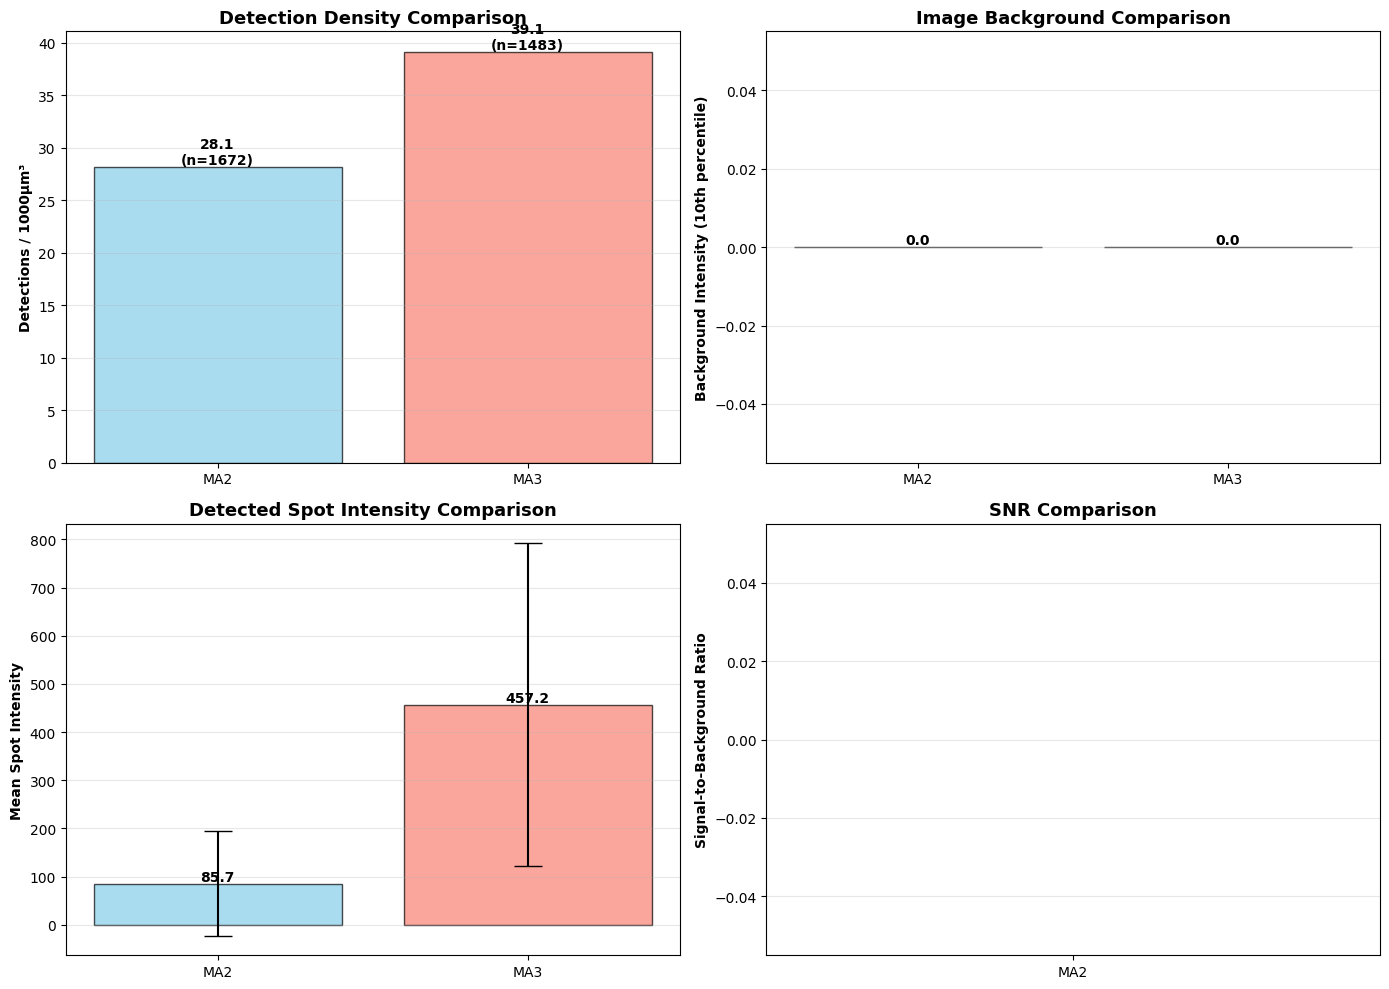


Analysis complete!


In [19]:


# ==============================================================================
# ANALYZE BOTH DATASETS
# ==============================================================================

results_MA2 = analyze_dataset_with_corrections(
    df=df_MA2,
    zarr_array=zarr_MA2,
    dataset_name='MA2',
    voxel_x=0.145,
    voxel_y=0.145,
    voxel_z=0.145,
    y_frac=y_fraction,
    z_range=(37, 113),
    amp_threshold=0,
    use_lightsheet_mask=True,
    frame_idx=0,
    channel_idx=0
)

results_MA3 = analyze_dataset_with_corrections(
    df=df_MA3,
    zarr_array=zarr_MA3,
    dataset_name='MA3',
    voxel_x=0.145,
    voxel_y=0.145,
    voxel_z=0.145,
    y_frac=y_fraction,
    z_range=(17, 113),
    amp_threshold=0,
    use_lightsheet_mask=True,
    frame_idx=0,
    channel_idx=0
)

# ==============================================================================
# COMPARISON SUMMARY
# ==============================================================================

print("\n" + "="*80)
print("COMPARISON SUMMARY - MA2 vs MA3")
print("="*80)

print("\n1. DETECTION DENSITY:")
print(f"   MA2: {results_MA2['density_per_1000um3']:.3f} detections/1000µm³ ({results_MA2['num_detections']} spots)")
print(f"   MA3: {results_MA3['density_per_1000um3']:.3f} detections/1000µm³ ({results_MA3['num_detections']} spots)")
if results_MA2['density_per_1000um3'] > 0:
    fold_density = results_MA3['density_per_1000um3'] / results_MA2['density_per_1000um3']
    print(f"   Fold change (MA3/MA2): {fold_density:.2f}x")

print("\n2. IMAGE BACKGROUND (10th percentile):")
print(f"   MA2: {results_MA2['background_10percentile']:.2f}")
print(f"   MA3: {results_MA3['background_10percentile']:.2f}")
diff_background = results_MA3['background_10percentile'] - results_MA2['background_10percentile']
pct_change = (diff_background / results_MA2['background_10percentile'] * 100) if results_MA2['background_10percentile'] > 0 else 0
print(f"   Difference (MA3-MA2): {diff_background:.2f} ({pct_change:+.1f}%)")

print("\n3. DETECTED SPOT INTENSITY:")
print(f"   MA2: {results_MA2['spot_mean_amplitude']:.2f} ± {results_MA2['spot_std_amplitude']:.2f}")
print(f"   MA3: {results_MA3['spot_mean_amplitude']:.2f} ± {results_MA3['spot_std_amplitude']:.2f}")
if not np.isnan(results_MA2['spot_mean_amplitude']) and not np.isnan(results_MA3['spot_mean_amplitude']):
    fold_intensity = results_MA3['spot_mean_amplitude'] / results_MA2['spot_mean_amplitude']
    print(f"   Fold change (MA3/MA2): {fold_intensity:.2f}x")

print("\n4. SIGNAL-TO-BACKGROUND RATIO:")
print(f"   MA2: {results_MA2['snr']:.2f}x")
print(f"   MA3: {results_MA3['snr']:.2f}x")

print("\n" + "="*80)

# ==============================================================================
# CREATE COMPARISON TABLE
# ==============================================================================

comparison_df = pd.DataFrame([results_MA2, results_MA3])
comparison_df = comparison_df.set_index('dataset')

print("\nDETAILED COMPARISON TABLE:")
print(comparison_df.to_string())

# ==============================================================================
# VISUALIZATIONS
# ==============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Detection Density
datasets = ['MA2', 'MA3']
densities = [results_MA2['density_per_1000um3'], results_MA3['density_per_1000um3']]
colors = ['skyblue', 'salmon']

bars = axes[0, 0].bar(datasets, densities, color=colors, edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('Detections / 1000µm³', fontweight='bold')
axes[0, 0].set_title('Detection Density Comparison', fontweight='bold', fontsize=13)
axes[0, 0].grid(axis='y', alpha=0.3)

for bar, val, count in zip(bars, densities, [results_MA2['num_detections'], results_MA3['num_detections']]):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.1f}\n(n={count})', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2: Background Levels
backgrounds = [results_MA2['background_10percentile'], results_MA3['background_10percentile']]

bars = axes[0, 1].bar(datasets, backgrounds, color=colors, edgecolor='black', alpha=0.7)
axes[0, 1].set_ylabel('Background Intensity (10th percentile)', fontweight='bold')
axes[0, 1].set_title('Image Background Comparison', fontweight='bold', fontsize=13)
axes[0, 1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, backgrounds):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Spot Intensities
spot_intensities = [results_MA2['spot_mean_amplitude'], results_MA3['spot_mean_amplitude']]
spot_stds = [results_MA2['spot_std_amplitude'], results_MA3['spot_std_amplitude']]

bars = axes[1, 0].bar(datasets, spot_intensities, yerr=spot_stds, 
                      color=colors, edgecolor='black', alpha=0.7, capsize=10)
axes[1, 0].set_ylabel('Mean Spot Intensity', fontweight='bold')
axes[1, 0].set_title('Detected Spot Intensity Comparison', fontweight='bold', fontsize=13)
axes[1, 0].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, spot_intensities):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: Signal-to-Background Ratio
snrs = [results_MA2['snr'], results_MA3['snr']]

bars = axes[1, 1].bar(datasets, snrs, color=colors, edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Signal-to-Background Ratio', fontweight='bold')
axes[1, 1].set_title('SNR Comparison', fontweight='bold', fontsize=13)
axes[1, 1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, snrs):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.1f}x', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAnalysis complete!")


In [20]:
def analyze_dataset_all_frames_with_corrections(df, zarr_array, dataset_name, voxel_x, voxel_y, voxel_z,
                                                y_frac=1.0, z_range=None, amp_threshold=0,
                                                use_lightsheet_mask=True, channel_idx=0):
    """
    Analyze all frames in a dataset with flexible corrections for volume and light sheet
    
    Parameters:
    - df: DataFrame with detections (must have 'frame' column and mu_x, mu_y, mu_z coordinates)
    - zarr_array: Zarr array with shape [T, C, Z, Y, X]
    - dataset_name: Name for reporting
    - voxel_x, voxel_y, voxel_z: Voxel sizes in microns
    - y_frac: Fraction of Y dimension to use (centered), default 1.0 (full range)
    - z_range: Tuple (z_min_pixel, z_max_pixel) to define Z range, or None for full range
    - amp_threshold: Amplitude threshold for filtering detections
    - use_lightsheet_mask: If True, only count detections within light sheet mask
    - channel_idx: Channel index for background calculation (default 0)
    
    Returns: dict with all metrics across all frames
    """
    print(f"\n{'='*80}")
    print(f"Analyzing {dataset_name} - ALL FRAMES WITH CORRECTIONS")
    print(f"{'='*80}")
    
    # Get dimensions
    print(f"\nZarr array shape: {zarr_array.shape}")
    print(f"Dimensions: T={zarr_array.shape[0]}, C={zarr_array.shape[1]}, Z={zarr_array.shape[2]}, Y={zarr_array.shape[3]}, X={zarr_array.shape[4]}")
    
    # Calculate X dimension
    full_x_um = zarr_array.shape[4] * voxel_x
    
    # Calculate CENTERED Y range
    y_pixels_total = zarr_array.shape[3]
    y_pixels_to_use = int(y_pixels_total * y_frac)
    y_min_pixel = int((y_pixels_total - y_pixels_to_use) / 2)
    y_max_pixel = y_min_pixel + y_pixels_to_use
    corrected_y_um = y_pixels_to_use * voxel_y
    
    # Calculate Z range
    if z_range is None:
        z_min_pixel = 0
        z_max_pixel = zarr_array.shape[2]
    else:
        z_min_pixel, z_max_pixel = z_range
    
    z_pixels_to_use = z_max_pixel - z_min_pixel
    corrected_z_um = z_pixels_to_use * voxel_z
    
    print(f"\nVolume dimensions:")
    print(f"  X: {full_x_um:.2f} µm ({zarr_array.shape[4]} pixels, full range)")
    print(f"  Y: {corrected_y_um:.2f} µm ({y_pixels_to_use} pixels, CENTERED from {y_min_pixel} to {y_max_pixel})")
    print(f"  Z: {corrected_z_um:.2f} µm ({z_pixels_to_use} pixels, from {z_min_pixel} to {z_max_pixel})")
    
    # Calculate light sheet mask if requested (using frame 0)
    if use_lightsheet_mask:
        print(f"\nCalculating light sheet mask (using frame 0)...")
        mask, illuminated_fraction = calculate_lightsheet_mask(zarr_array, frame_idx=0, channel_idx=channel_idx)
        
        # Crop mask to the Y and Z ranges
        mask_cropped = mask[z_min_pixel:z_max_pixel, y_min_pixel:y_max_pixel, :]
        
        # Calculate corrected volume based on illuminated voxels
        illuminated_voxels = np.sum(mask_cropped)
        corrected_volume_um3 = illuminated_voxels * voxel_x * voxel_y * voxel_z
        
        print(f"  Illuminated voxels in corrected region: {illuminated_voxels:,}")
        print(f"  Corrected volume (light sheet only): {corrected_volume_um3:.2f} µm³")
    else:
        # Use full rectangular volume
        corrected_volume_um3 = full_x_um * corrected_y_um * corrected_z_um
        mask_cropped = None
        print(f"  Corrected volume (rectangular): {corrected_volume_um3:.2f} µm³")
    
    # Get all unique frames
    frames = sorted(df['frame'].unique())
    num_frames = len(frames)
    
    print(f"\nTotal frames in dataset: {num_frames}")
    print(f"Analyzing frames: {frames[0]} to {frames[-1]}")
    
    # Arrays to store per-frame metrics
    densities = []
    detection_counts = []
    
    # Loop through each frame
    for frame_num in frames:
        # Get detections for this frame
        df_frame = df[df['frame'] == frame_num]
        
        # Filter to corrected Y and Z ranges
        df_corrected = df_frame[
            (df_frame['mu_y'] >= y_min_pixel) & (df_frame['mu_y'] <= y_max_pixel) &
            (df_frame['mu_z'] >= z_min_pixel) & (df_frame['mu_z'] <= z_max_pixel)
        ]
        
        # Apply light sheet mask filter if requested
        if use_lightsheet_mask and mask_cropped is not None:
            # Check each detection to see if it falls within the mask
            detections_in_mask = []
            for idx, row in df_corrected.iterrows():
                # Convert to integer pixel coordinates (relative to cropped region)
                z_idx = int(np.round(row['mu_z'])) - z_min_pixel
                y_idx = int(np.round(row['mu_y'])) - y_min_pixel
                x_idx = int(np.round(row['mu_x']))
                
                # Check bounds
                if (0 <= z_idx < mask_cropped.shape[0] and
                    0 <= y_idx < mask_cropped.shape[1] and
                    0 <= x_idx < mask_cropped.shape[2]):
                    # Check if this voxel is illuminated
                    if mask_cropped[z_idx, y_idx, x_idx]:
                        detections_in_mask.append(idx)
            
            df_corrected = df_corrected.loc[detections_in_mask]
        
        # Count detections
        num_detections = len(df_corrected)
        detection_counts.append(num_detections)
        
        # Calculate density for this frame
        density = num_detections / corrected_volume_um3 if corrected_volume_um3 > 0 else 0
        densities.append(density)
    
    # Convert to numpy arrays for statistics
    densities = np.array(densities)
    detection_counts = np.array(detection_counts)
    
    # Calculate statistics
    avg_density = np.mean(densities)
    std_density = np.std(densities)
    avg_detections = np.mean(detection_counts)
    std_detections = np.std(detection_counts)
    
    print(f"\nDetection counts per frame:")
    print(f"  Mean: {avg_detections:.1f} ± {std_detections:.1f} detections/frame")
    print(f"  Range: {detection_counts.min()} - {detection_counts.max()}")
    
    print(f"\nDetection density:")
    print(f"  Mean: {avg_density:.6f} ± {std_density:.6f} detections/µm³")
    print(f"  Mean: {avg_density*1000:.3f} ± {std_density*1000:.3f} detections/1000µm³")
    print(f"  Range: {densities.min()*1000:.3f} - {densities.max()*1000:.3f} detections/1000µm³")
    
    # Calculate background from frame 0
    image_frame0 = zarr_array[0, channel_idx, z_min_pixel:z_max_pixel, y_min_pixel:y_max_pixel, :]
    background_10percentile = np.percentile(image_frame0, 10)
    background_mean = np.mean(image_frame0)
    background_median = np.median(image_frame0)
    
    print(f"\nImage background (frame 0, channel {channel_idx}):")
    print(f"  10th percentile: {background_10percentile:.2f}")
    print(f"  Mean: {background_mean:.2f}")
    print(f"  Median: {background_median:.2f}")
    
    # Get all detections in corrected ranges (all frames)
    df_all_corrected = df[
        (df['mu_y'] >= y_min_pixel) & (df['mu_y'] <= y_max_pixel) &
        (df['mu_z'] >= z_min_pixel) & (df['mu_z'] <= z_max_pixel)
    ]
    
    # Apply light sheet mask to all detections if requested
    if use_lightsheet_mask and mask_cropped is not None:
        all_detections_in_mask = []
        for idx, row in df_all_corrected.iterrows():
            z_idx = int(np.round(row['mu_z'])) - z_min_pixel
            y_idx = int(np.round(row['mu_y'])) - y_min_pixel
            x_idx = int(np.round(row['mu_x']))
            
            if (0 <= z_idx < mask_cropped.shape[0] and
                0 <= y_idx < mask_cropped.shape[1] and
                0 <= x_idx < mask_cropped.shape[2]):
                if mask_cropped[z_idx, y_idx, x_idx]:
                    all_detections_in_mask.append(idx)
        
        df_all_corrected = df_all_corrected.loc[all_detections_in_mask]
    
    positive_spots = df_all_corrected[df_all_corrected['amplitude'] > amp_threshold]
    
    if len(positive_spots) > 0:
        avg_amplitude = positive_spots['amplitude'].mean()
        std_amplitude = positive_spots['amplitude'].std()
        median_amplitude = positive_spots['amplitude'].median()
        percentile_25 = positive_spots['amplitude'].quantile(0.25)
        percentile_75 = positive_spots['amplitude'].quantile(0.75)
        percentile_90 = positive_spots['amplitude'].quantile(0.90)
        
        print(f"\nDetected spot intensities (all frames, amplitude > {amp_threshold}):")
        print(f"  Count: {len(positive_spots)} total spots")
        print(f"  Mean: {avg_amplitude:.2f} ± {std_amplitude:.2f}")
        print(f"  Median: {median_amplitude:.2f}")
        print(f"  25th-75th percentile: {percentile_25:.2f} - {percentile_75:.2f}")
        print(f"  90th percentile: {percentile_90:.2f}")
        
        snr_mean = avg_amplitude / background_10percentile if background_10percentile > 0 else np.inf
        snr_90percentile = percentile_90 / background_10percentile if background_10percentile > 0 else np.inf
        
        print(f"\nSignal-to-Background Ratios:")
        print(f"  Mean spot / Background: {snr_mean:.2f}x")
        print(f"  90th percentile / Background: {snr_90percentile:.2f}x")
    else:
        avg_amplitude = np.nan
        std_amplitude = np.nan
        median_amplitude = np.nan
        percentile_90 = np.nan
        snr_mean = np.nan
        snr_90percentile = np.nan
    
    # Return all metrics
    return {
        'dataset': dataset_name,
        'num_frames': num_frames,
        'avg_detections_per_frame': avg_detections,
        'std_detections_per_frame': std_detections,
        'avg_density_per_um3': avg_density,
        'std_density_per_um3': std_density,
        'avg_density_per_1000um3': avg_density * 1000,
        'std_density_per_1000um3': std_density * 1000,
        'corrected_volume_um3': corrected_volume_um3,
        'y_frac': y_frac,
        'z_range': (z_min_pixel, z_max_pixel),
        'use_lightsheet_mask': use_lightsheet_mask,
        'background_10percentile': background_10percentile,
        'background_mean': background_mean,
        'background_median': background_median,
        'spot_mean_amplitude': avg_amplitude,
        'spot_std_amplitude': std_amplitude,
        'spot_median_amplitude': median_amplitude,
        'spot_90percentile_amplitude': percentile_90,
        'snr_mean': snr_mean,
        'snr_90percentile': snr_90percentile,
        'spot_count': len(positive_spots) if len(positive_spots) > 0 else 0,
        'densities_per_frame': densities,  # Array of densities for plotting
        'detection_counts_per_frame': detection_counts  # Array of counts for plotting
    }

# ==============================================================================
# ANALYZE BOTH DATASETS (ALL FRAMES)
# ==============================================================================

results_MA2 = analyze_dataset_all_frames_with_corrections(
    df=df_MA2,
    zarr_array=zarr_MA2,
    dataset_name='MA2',
    voxel_x=0.145,
    voxel_y=0.145,
    voxel_z=0.145,
    y_frac=2/3,
    z_range=(37, 113),
    amp_threshold=0,
    use_lightsheet_mask=True,
    channel_idx=0
)

results_MA3 = analyze_dataset_all_frames_with_corrections(
    df=df_MA3,
    zarr_array=zarr_MA3,
    dataset_name='MA3',
    voxel_x=0.145,
    voxel_y=0.145,
    voxel_z=0.145,
    y_frac=2/3,
    z_range=(17, 113),
    amp_threshold=0,
    use_lightsheet_mask=True,
    channel_idx=0
)



Analyzing MA2 - ALL FRAMES WITH CORRECTIONS

Zarr array shape: (128, 2, 114, 2048, 406)
Dimensions: T=128, C=2, Z=114, Y=2048, X=406

Volume dimensions:
  X: 58.87 µm (406 pixels, full range)
  Y: 197.92 µm (1365 pixels, CENTERED from 341 to 1706)
  Z: 11.02 µm (76 pixels, from 37 to 113)

Calculating light sheet mask (using frame 0)...
Intensity threshold (5th percentile): 0.00
Illuminated fraction: 0.5102
  Illuminated voxels in corrected region: 21,678,930
  Corrected volume (light sheet only): 66090.93 µm³

Total frames in dataset: 128
Analyzing frames: 0 to 127

Detection counts per frame:
  Mean: 1700.3 ± 45.7 detections/frame
  Range: 1582 - 1857

Detection density:
  Mean: 0.025726 ± 0.000691 detections/µm³
  Mean: 25.726 ± 0.691 detections/1000µm³
  Range: 23.937 - 28.098 detections/1000µm³

Image background (frame 0, channel 0):
  10th percentile: 0.00
  Mean: 57.37
  Median: 94.00

Detected spot intensities (all frames, amplitude > 0):
  Count: 217633 total spots
  Mean: 75

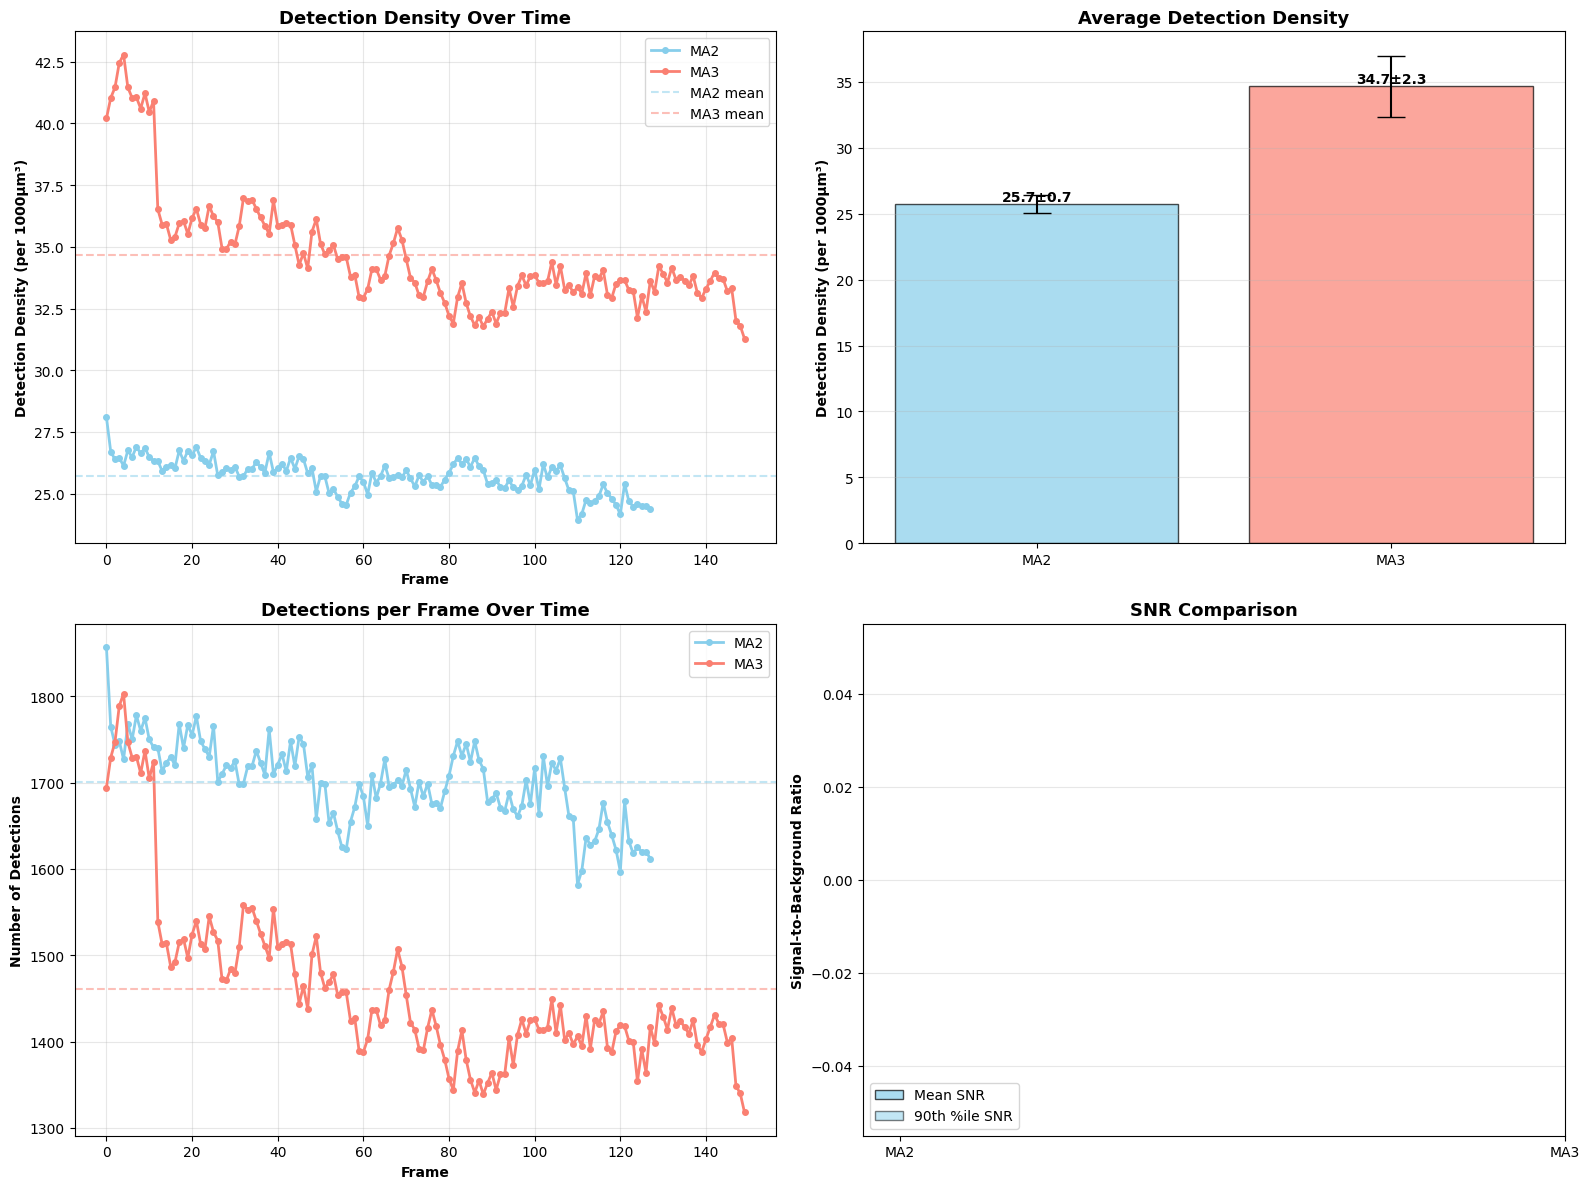

In [21]:
# ==============================================================================
# VISUALIZATIONS
# ==============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Density per frame over time
axes[0, 0].plot(results_MA2['densities_per_frame'] * 1000, 'o-', label='MA2', color='skyblue', linewidth=2, markersize=4)
axes[0, 0].plot(results_MA3['densities_per_frame'] * 1000, 'o-', label='MA3', color='salmon', linewidth=2, markersize=4)
axes[0, 0].axhline(results_MA2['avg_density_per_1000um3'], color='skyblue', linestyle='--', alpha=0.5, label='MA2 mean')
axes[0, 0].axhline(results_MA3['avg_density_per_1000um3'], color='salmon', linestyle='--', alpha=0.5, label='MA3 mean')
axes[0, 0].set_xlabel('Frame', fontweight='bold')
axes[0, 0].set_ylabel('Detection Density (per 1000µm³)', fontweight='bold')
axes[0, 0].set_title('Detection Density Over Time', fontweight='bold', fontsize=13)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Average density comparison
datasets = ['MA2', 'MA3']
avg_densities = [results_MA2['avg_density_per_1000um3'], results_MA3['avg_density_per_1000um3']]
std_densities = [results_MA2['std_density_per_1000um3'], results_MA3['std_density_per_1000um3']]
colors = ['skyblue', 'salmon']

bars = axes[0, 1].bar(datasets, avg_densities, yerr=std_densities, 
                      color=colors, edgecolor='black', alpha=0.7, capsize=10)
axes[0, 1].set_ylabel('Detection Density (per 1000µm³)', fontweight='bold')
axes[0, 1].set_title('Average Detection Density', fontweight='bold', fontsize=13)
axes[0, 1].grid(axis='y', alpha=0.3)

for bar, val, std in zip(bars, avg_densities, std_densities):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.1f}±{std:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 3: Detections per frame
axes[1, 0].plot(results_MA2['detection_counts_per_frame'], 'o-', label='MA2', color='skyblue', linewidth=2, markersize=4)
axes[1, 0].plot(results_MA3['detection_counts_per_frame'], 'o-', label='MA3', color='salmon', linewidth=2, markersize=4)
axes[1, 0].axhline(results_MA2['avg_detections_per_frame'], color='skyblue', linestyle='--', alpha=0.5)
axes[1, 0].axhline(results_MA3['avg_detections_per_frame'], color='salmon', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Frame', fontweight='bold')
axes[1, 0].set_ylabel('Number of Detections', fontweight='bold')
axes[1, 0].set_title('Detections per Frame Over Time', fontweight='bold', fontsize=13)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: SNR comparison
snr_means = [results_MA2['snr_mean'], results_MA3['snr_mean']]
snr_90s = [results_MA2['snr_90percentile'], results_MA3['snr_90percentile']]

x = np.arange(len(datasets))
width = 0.35

bars1 = axes[1, 1].bar(x - width/2, snr_means, width, label='Mean SNR', 
                       color=colors, edgecolor='black', alpha=0.7)
bars2 = axes[1, 1].bar(x + width/2, snr_90s, width, label='90th %ile SNR',
                       color=colors, edgecolor='black', alpha=0.5)

axes[1, 1].set_ylabel('Signal-to-Background Ratio', fontweight='bold')
axes[1, 1].set_title('SNR Comparison', fontweight='bold', fontsize=13)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(datasets)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()